<a href="https://colab.research.google.com/github/SampMark/Machine-Learning/blob/main/Softmax_Multinomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Função Softmax**

A função Softmax é uma generalização da função logística para múltiplas classes. É amplamente utilizada em aprendizado de máquina, especialmente em problemas de classificação multi-classe, como a última camada de uma rede neural.

O objetivo da Softmax é transformar um vetor de números reais em uma distribuição de probabilidade, em que cada elemento representa a probabilidade de pertencer a uma determinada classe.

### **Definição Matemática**

Dado um vetor de logits
$$
z = (z_0, z_1, \ldots, z_{k-1}),
$$

onde cada $z_j$ é o produto interno $\theta_j \cdot x$, isto é, parâmetros do modelo $\theta_j$ multiplicados pelas entradas de dados $x$. As quantidades $z_j$ são frequentemente chamadas de **logits** ou **pontuações**.

Ou seja, a **função Softmax** $
h({x})$ converterá um vetor de valores (chamados de logits) em probabilidades normalizadas, onde cada probabilidade está no intervalo $[0,1]$ e a soma de todas é 1, cuja fórmula básica é:

$$
h({x}) = \frac{1}{\sum_{j=0}^{k-1} e^{\theta_j \cdot {x}/\tau}}
\begin{bmatrix}
e^{\theta_0 \cdot {x}/\tau} \\
e^{\theta_1 \cdot {x}/\tau} \\
\vdots \\
e^{\theta_{k-1} \cdot {x}/\tau}
\end{bmatrix},
$$

Onde:

*   **$x$**: é o vetor de entrada (geralmente, os logits ou scores de cada classe, antes da normalização),$x^{(i)}$ representa o i-ésimo dado de entrada.
*   **$θ_j$**: é o vetor de pesos associado à classe *j*.  Cada classe tem seu próprio conjunto de pesos.  O produto $θ_j ⋅ x$ é um produto escalar (ou produto interno) entre o vetor de pesos da classe *j* e o vetor de entrada *x*.  Isso representa o "score" ou "afinidade" de *x* com a classe *j*.
*   **$τ$**: é o "parâmetro de temperatura" (_temperature parameter_), controla a "suavidade" da distribuição de probabilidade resultante, ou seja, é útil para calibrar a “confiança” ou a “entropia” das predições, ajustando o quão “concentrada” a distribuição de probabilidades ficará.
    *   `τ → 0`: quando a função Softmax se aproxima de uma função "argmax", ou seja, a classe com o maior score recebe probabilidade 1, e as outras recebem 0.
    *   `τ → ∞`: quando todas as classes tendem a ter probabilidades iguais (distribuição uniforme).
    *   Valores intermediários de τ suavizam a distribuição, permitindo que classes com scores menores ainda tenham alguma probabilidade.
*   **$k$**: é o número total de classes.
*   **$\sum_{j=0}^{k-1}$**:  o somatório no denominador garante que a soma das probabilidades de todas as classes seja igual a 1, formando uma distribuição de probabilidade válida.
*   **$[e^{θ_0 ⋅ x / τ}, ..., e^{θ_k-1 ⋅ x / τ}]$**: representa o vetor de probabilidades, em que cada elemento é a probabilidade de $x$ pertencer à respectiva classe, *antes* da normalização.

Sinteticamente, a função Softmax calcula a probabilidade de cada classe, exponenciando o score de cada classe (ajustado pela "temperatura") e, em seguida, normaliza esses valores dividindo pela soma de todos os exponenciais.

### **Problemas Numéricos: truque de estabilidade numérica e a solução com 'c'**

Porém há um problema crucial na implementação prática da Softmax: o uso da **função exponencial**.

Os termos **$e^{\theta_j \cdot {x}/\tau}$** podem se tornar extremamente grandes ou extremamente pequenos, dependendo dos valores de $θ_j$, $x$ e $τ$, com risco de gerar dois problemas:

*   **Overflow:** se **$\theta_j \cdot {x}/\tau$** for muito grande (positivo), a exponencial `e^(θj ⋅ x / τ)` pode exceder a capacidade de representação do computador, resultando em um erro de "overflow" (geralmente representado como `inf` ou `NaN`).
*   **Underflow:** se **$\theta_j \cdot {x}/\tau$** for muito pequeno (negativo), `e^(θj ⋅ x / τ)` pode se aproximar tanto de zero que o computador o arredonda para zero, perdendo precisão.

A solução proposta, e matematicamente válida, é subtrair uma constante *c* de cada expoente *antes* de calcular a exponencial, resultando na seguinte equação:

$$
h({x}) = \frac{1}{\sum_{j=0}^{k-1} e^{[\theta_j \cdot {x}/\tau]-c}}
\begin{bmatrix}
e^{[\theta_0 \cdot {x}/\tau]-c} \\
e^{[\theta_1 \cdot {x}/\tau]-c} \\
\vdots \\
e^{[\theta_{k-1} \cdot {x}/\tau]-c}
\end{bmatrix},
$$

Observe que subtrair uma constante \(c\) do numerador e do denominador **não altera o resultado** (pois o fator $e^{-c}$ é comum em todos os termos e se cancela). Entretanto, esse procedimento reduz o valor máximo que entra na exponencial para 0 (ou seja, $\tilde{z}_\text{max} = 0$), prevenindo estouros numéricos. Logo, a chave é a escolha adequada de *c*.

#### **A escolha de 'c'**

A escolha adequada de  $c = max_j θ_j ⋅ x / τ$ é crucial para:

*   **Evitar overflow:**  Ao subtrair o maior valor de `θj ⋅ x / τ` de todos os expoentes, garantimos que o maior expoente possível seja 0 (pois será `max(θj ⋅ x / τ) - max(θj ⋅ x / τ)`).  `e^0 = 1`, então não haverá overflow. Todos os outros expoentes serão negativos ou zero, então as exponenciais estarão no intervalo (0, 1].
*   **Minimizar o underflow:**  embora não elimine completamente o underflow (um número muito pequeno ainda pode ser arredondado para zero), essa escolha minimiza o problema. Ao manter o maior expoente em 0, estamos o mais longe possível da região de underflow.
*  **Não afetar o resultado:** como demonstrado na derivação, subtrair uma constante de todos os expoentes não muda as probabilidades relativas (após a normalização).

### **Interpretação Geométrica e Probabilística**

- **Geometricamente**

  A aplicação da função Softmax pode ser vista como um mapeamento do espaço real $\mathbb{R}^K$ para o simplex $ \Delta^{K-1} $ – o conjunto de vetores de probabilidade. Para $K=3$, por exemplo, isso corresponde a transformar as pontuações em pontos dentro de um "triângulo".
  
- **Probabilisticamente**

  A função transforma as “confidências” do modelo (os logits) em uma distribuição de probabilidade que permite interpretar quantitativamente o quanto o modelo “acredita” em cada classe. Esse aspecto é fundamental tanto para a tomada de decisão (via argmax, por exemplo) quanto para a definição de uma função de perda – normalmente a entropia cruzada (cross-entropy) – que é diferenciável e adequada para treinamento via gradiente descendente.

Além disso, a suavidade da função Softmax é crucial para que as atualizações durante o treinamento sejam contínuas e bem comportadas, contribuindo para a eficiência do [**gradiente descendente**](https://github.com/SampMark/Machine-Learning/blob/main/Gradient_Descent_and_Regularization.ipynb).


### **Considerações**

A função Softmax é uma técnica essencial em classificação multi-classe.  Pois permite a estabilização numérica, usando a subtração do maior _score_. Isto é crucial para evitar erros de _overflow_ ou _underflow_, garantindo cálculos das probabilidades mais precisos e confiáveis, em virtude  do parâmetro de temperatura e escolha da constante.

Além disso, a função Softmax é amplamente utilizada em arquiteturas de [**deep learning**](https://github.com/SampMark/Deep-Learning), seja em redes neurais simples para classificação ou nas camadas finais de Redes Neurais Convolucionais (CNN) e _transformers_.


In [ ]:
# @title Importando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# @title **Cálculo das probabilidades usando Softmax**

def compute_probabilities(X, theta, temp_parameter):
    """
    Calcula as probabilidades Softmax para cada ponto de dados em X.

    Args:
        X (np.ndarray): Matriz (n, d) de n pontos de dados com d features.
        theta (np.ndarray): Matriz (k, d) de parâmetros, onde cada linha corresponde a uma classe.
        temp_parameter (float): Parâmetro de temperatura para suavização.

    Returns:
        np.ndarray: Matriz (k, n) onde H[j][i] é a probabilidade de X[i] pertencer à classe j.
    """

    # Calcula os scores: theta * X^T e aplica a temperatura
    scores = np.dot(theta, X.T) / temp_parameter  # Shape (k, n)

    # Estabilidade numérica: subtrai o máximo de cada coluna (por ponto de dados)
    scores -= np.max(scores, axis=0, keepdims=True)

    # Exponencia os scores ajustados
    exp_scores = np.exp(scores)  # Shape (k, n)

    # Calcula a soma das exponenciais por ponto de dados (eixo 0)
    sum_exp = np.sum(exp_scores, axis=0, keepdims=True)  # Shape (1, n)

    # Normaliza para obter as probabilidades
    probabilities = exp_scores / sum_exp  # Shape (k, n)

    return probabilities

In [25]:
# @title Exemplo de uso 1, ponto único
X = np.array([2.0, 1.0, 0.1])
theta = np.array([[1.0, 0.5, 0.2],
                  [0.1, 1.2, 0.8],
                  [-0.5, 0.3, 1.5]])
temp = 1.0

# Calcula probabilidades
prob = compute_probabilities(X, theta, temp)
print("Probabilidades:\n", prob)

Probabilidades:
 [0.71434907 0.25249002 0.03316091]


In [26]:
# @title Exemplo de uso 2, dois pontos
X = np.array([[1.0, 2.0], [3.0, 4.0]])  # 2 pontos, 2 features
theta = np.array([[0.5, 0.1], [0.2, 0.8]])  # 2 classes, 2 features
temp = 1.0

# Calcula probabilidades
prob = compute_probabilities(X, theta, temp)
print("Probabilidades:\n", prob)

Probabilidades:
 [[0.24973989 0.13010847]
 [0.75026011 0.86989153]]


In [37]:
# @title **Cálculo de probabilidades Softmax para um ou mais pontos de dados**

def softmax(X, theta, temp_parameter):
    """
    Calcula as probabilidades Softmax para um ou mais pontos de dados.

    Parâmetros:
        X (np.ndarray): Vetor (d,) ou matriz (n, d) de dados, onde `d` é o número de features.
        theta (np.ndarray): Matriz (k, d) de parâmetros. Cada linha `j` corresponde à classe `j`.
        temp_parameter (float, opcional): Parâmetro de temperatura (> 0). Valores menores aumentam
                                          a "confiança" da distribuição. Padrão: 1.0.
    Retorna:
        np.ndarray:
            - Se `X` for um vetor (d,), retorna um vetor (k,) com as probabilidades para cada classe.
            - Se `X` for uma matriz (n, d), retorna uma matriz (k, n) onde cada coluna corresponde
              às probabilidades de um ponto de dados.
    Exceções:
        ValueError: Se `temp_parameter` ≤ 0.
    """
    if temp_parameter <= 0:
        raise ValueError("temp_parameter deve ser maior que 0.")

    # Garante que X seja 2D (n, d)
    original_shape = X.shape
    if X.ndim == 1:
        X = X.reshape(1, -1)  # Transforma em matriz (1, d)

    # Calcula os scores (k, n) e aplica temperatura
    scores = np.dot(theta, X.T) / temp_parameter  # Shape (k, n)

    # Estabilidade numérica: subtrai o máximo de cada coluna (por ponto de dados)
    scores -= np.max(scores, axis=0, keepdims=True)  # Evita overflow

    # Exponenciação e normalização
    exp_scores = np.exp(scores)  # Shape (k, n)
    probabilities = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)  # Normalização

    # Retorna vetor (k,) se a entrada for um vetor
    if len(original_shape) == 1:
        probabilities = probabilities.squeeze(axis=1)  # Remove dimensão extra

    return probabilities

In [38]:
# @title Caso 1: Ponto único
X = np.array([2.0, 1.0, 0.1])
theta = np.array([[1.0, 0.5, 0.2],
                  [0.1, 1.2, 0.8],
                  [-0.5, 0.3, 1.5]])
temp_parameter = 1.0

# Calcula probabilidades
print("Probabilidades (ponto único):\n", softmax(X, theta, temp_parameter))

Probabilidades (ponto único):
 [0.71434907 0.25249002 0.03316091]


In [39]:
# @title Caso 2: Dois pontos
X = np.array([[1.0, 2.0], [3.0, 4.0]])  # 2 pontos, 2 features
theta = np.array([[0.5, 0.1], [0.2, 0.8]])  # 2 classes, 2 features
temp_parameter = 1.0

# Calcula probabilidades
print("Probabilidades (dois pontos):\n", softmax(X, theta, temp_parameter))

Probabilidades (dois pontos):
 [[0.24973989 0.13010847]
 [0.75026011 0.86989153]]


In [44]:
# @title Caso 3: Pontos com valores extremos (teste de estabilidade)
X_grande = np.array([[1000, 1001, 999],  # Pontos extremos
                     [2.0, 1.0, 0.1]])  # Ponto normal

temp_parameter = 1.0

# theta com dimensões apropriadas para X_grande
# na forma (número de classes, número de recursos em X_grande)
# Assumindo 3 classes
theta = np.array([[1.0, 0.5, 0.2],
                  [0.1, 1.2, 0.8],
                  [-0.5, 0.3, 1.5]])

# Calcula probabilidades
print("\nProbabilidades (pontos extremos):\n", softmax(X_grande, theta, temp_parameter))


Probabilidades (pontos extremos):
 [[1.73291711e-174 7.14349068e-001]
 [1.00000000e+000 2.52490023e-001]
 [0.00000000e+000 3.31609087e-002]]


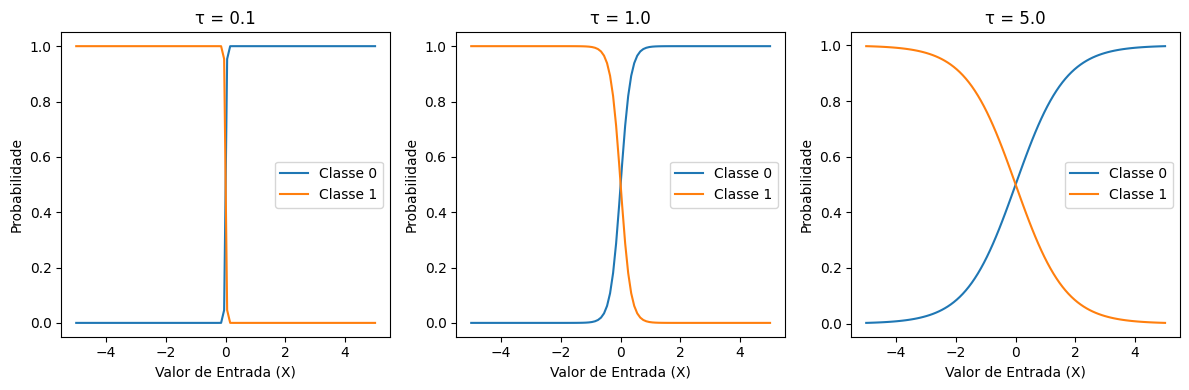

In [57]:
# @title **Efeitos da variação do parâmetro de temperatura**
theta = np.array([[2.0, -1.0, 0.5],   # Classe 0: favorece x positivo
                  [-2.0, 1.0, -0.5]]) # Classe 1: favorece x negativo

theta = np.array([[3.0], [-3.0]])  # Pesos fixos: classe 0 favorece X alto, classe 1 X baixo
X = np.linspace(-5, 5, 100).reshape(-1, 1)  # Apenas uma feature (x)

# Cálculo Simplificado
probabilities = []
for temp in [0.1, 1.0, 5.0]:
    probs = softmax(X, theta, temp) # 'probs' will now have shape (2, 100)
    probabilities.append(probs)

# Plotagem Clara com Subplots
plt.figure(figsize=(12, 4))
for i, temp in enumerate([0.1, 1.0, 5.0]):
    plt.subplot(1, 3, i+1)

    # Changed: Use X.squeeze() to match the dimensions
    plt.plot(X.squeeze(), probabilities[i][0, :], label="Classe 0")  # Probabilities for class 0
    plt.plot(X.squeeze(), probabilities[i][1, :], label="Classe 1")  # Probabilities for class 1

    plt.title(f"τ = {temp}")
    plt.xlabel("Valor de Entrada (X)")
    plt.ylabel("Probabilidade")
    plt.legend()
plt.tight_layout()
plt.show()

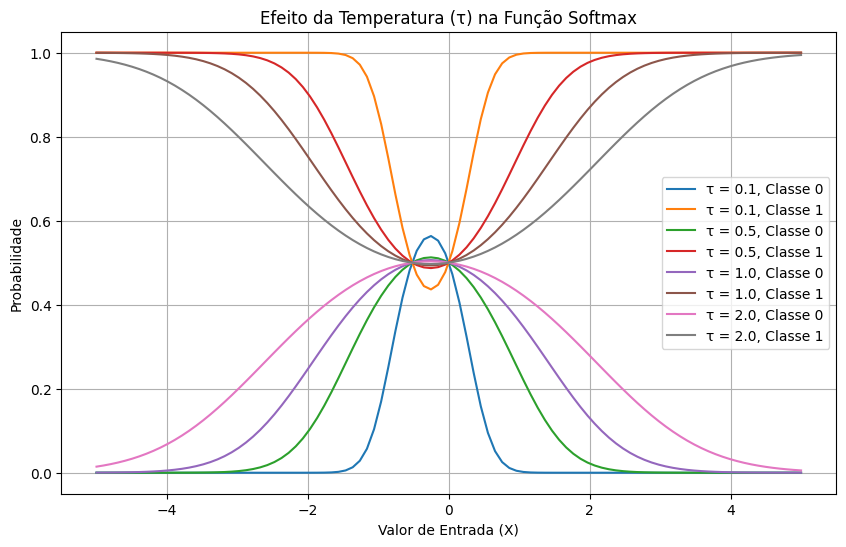

In [51]:
# @title Gráfico: curvas de probabilidades das classes, variação de X para diferentes τ

# Gera 100 valores igualmente espaçados entre -5 e 5
X = np.linspace(-5, 5, 100)

# Configuração das classes e features
num_classes = 2   # Número de classes (ex: classe 0 e classe 1)
num_features = 3  # Número de features por ponto de dados (ex: x, x², x/2)

# Gera pesos aleatórios para as classes (2 classes × 3 features)
theta = np.random.rand(num_classes, num_features)

# Valores de temperatura a serem testados
temperatures = [0.1, 0.5, 1.0, 2.0]
probabilities = []

for temp in temperatures:
    probs_for_temp = []
    for x_val in X:
        # Cria um vetor de features para o valor x_val
        x = np.array([x_val, x_val**2, x_val/2])  # Features: [x, x², x/2]

        # Calcula as probabilidades Softmax usando a função definida anteriormente
        probs = softmax(x, theta, temp_parameter=temp)
        probs_for_temp.append(probs)  # Armazena as probabilidades

    probabilities.append(np.array(probs_for_temp))  # Armazena resultados da temperatura atual

plt.figure(figsize=(10, 6))

# Plota as probabilidades para cada temperatura
for i, temp in enumerate(temperatures):
    plt.plot(X, probabilities[i][:, 0], label=f"τ = {temp}, Classe 0")  # Probabilidades da classe 0
    plt.plot(X, probabilities[i][:, 1], label=f"τ = {temp}, Classe 1")  # Probabilidades da classe 1

# Configurações do gráfico
plt.xlabel("Valor de Entrada (X)")
plt.ylabel("Probabilidade")
plt.title("Efeito da Temperatura (τ) na Função Softmax")
plt.legend()
plt.grid(True)
plt.show()

## **Referências**

* BRIDLE, J. S. Probabilistic Interpretation of Feedforward Classification Network Outputs. In: FOGELMAN SOULIÉ, F.; HÉRAULT, J. (Ed.). **Neurocomputing: Algorithms, Architectures and Applications**. Berlin: Springer Berlin Heidelberg, 1990. p. 227-236.

* GOODFELLOW, I.; BENGIO, Y.; COURVILLE, A. Deep Learning. Cambridge: MIT Press, 2016. Capítulo 6: Softmax e Regressão Logística. Disponível em: [https://www.deeplearningbook.org/](https://www.deeplearningbook.org/). Acesso em: 26 de fev. 2025.

* MIRANDA, L. J. Understanding Softmax and the Negative Log-Likelihood. Disponível em: [https://ljvmiranda921.github.io/notebook/2017/08/13/softmax-and-the-negative-log-likelihood/](https://ljvmiranda921.github.io/notebook/2017/08/13/softmax-and-the-negative-log-likelihood/). Acesso em: 27 de fev. 2025.

* STANFORD UNIVERSITY. CS231n: Convolutional Neural Networks for Visual Recognition: Linear Classification: Softmax. Disponível em: [http://cs231n.github.io/linear-classify/#softmax](http://cs231n.github.io/linear-classify/#softmax). Acesso em: 26 de fev. 2025.

* WIKIPEDIA. Softmax function. Disponível em: [https://en.wikipedia.org/wiki/Softmax_function](https://en.wikipedia.org/wiki/Softmax_function). Acesso em: 24 de fev. 2025.